# Phaedrus Screening
This notebook demonstrates the Phaedrus screening mechanism using the unified scalar BVP solver:
- **§1** — Single solve: full nonlinear vs linearised reference, with estimated Phaedrus screening radius.
- **§2** — Sweep over central overdensity $\delta_c$: slope $n(x) = d\ln[x^2|Q_x|]/d\ln x$ coloured by $\log_{10}(\delta_c)$, with per-branch screening radii marked.

Note: This notebook reads modules directly from `../main` so you can run it inside this repo without installing a package.

In [57]:
# Setup: import local modules from ../main
import sys, os, importlib
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
main_dir = os.path.join(repo_root, "main")
if main_dir not in sys.path:
    sys.path.insert(0, main_dir)
print("Added to sys.path:", main_dir)

# Reload dependency chain: physics_utils → plotting → escut
import physics_utils as _physics_mod
importlib.reload(_physics_mod)
import plotting as _plotting_mod
importlib.reload(_plotting_mod)
import escut
importlib.reload(escut)

# Single-surface import: pull everything from escut
from escut import (
    # core solver
    solve_scalar_bvp,
    # plotting helpers
    plot_double_panel,
    compute_n_slope,
)

import numpy as np
import matplotlib.pyplot as plt

Added to sys.path: /Users/sergi/Qsolver/main


## 1) Simple case: full vs linear
We solve with kinetic Phaedrus coefficients $D, E > 0$ and compare to a linearised ($D=E=0$) reference.
The Phaedrus screening radius is where $D|Q|/A = 1$ (kinetic denominator doubles).

[warn] exterior μ contribution (5.647e+01) is >0.1% of interior μ (1.193e+02); enabling asymptotic_bc
[warn] exterior μ contribution (5.647e+01) is >0.1% of interior μ (1.193e+02); consider reducing delta_inf or using asymptotic_bc
[warn] exterior μ contribution (5.647e+01) is >0.1% of interior μ (1.193e+02); enabling asymptotic_bc


/Users/sergi/Qsolver/main/physics_utils.py:131: RuntimeWarning: invalid value encountered in scalar divide
  delta_c, delta_inf, eps_edge, S : see mu_for_tanh_step


[warn] exterior μ contribution (5.647e+01) is >0.1% of interior μ (1.193e+02); consider reducing delta_inf or using asymptotic_bc


/Users/sergi/Qsolver/main/plotting.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _setup_delta_c_colormap = _cmap_setup


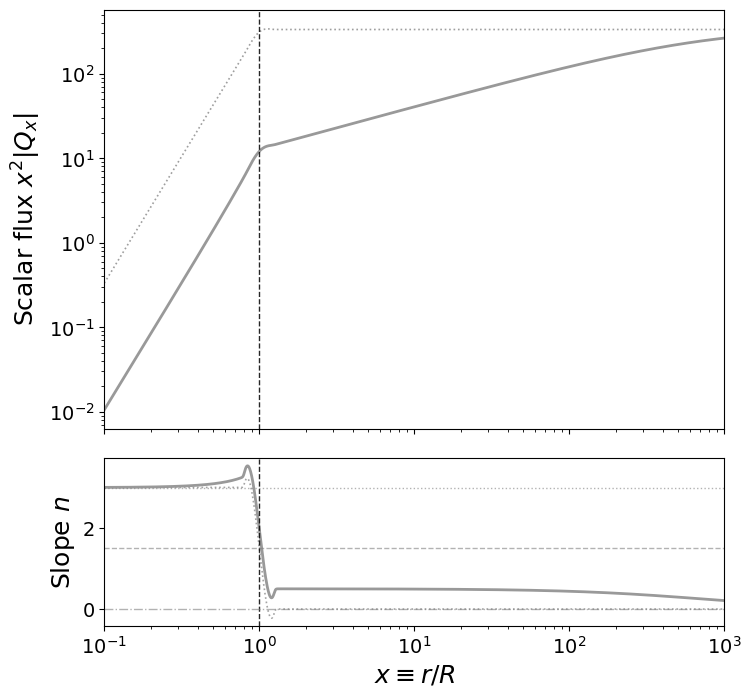

In [58]:
A = 1.0
B = 0
C = 0
D = 1e0
E = 1e0
F = 0
S = 1.0
delta_c   = 1e3
delta_inf = 0
eps_edge  = 0.015

common_kwargs = dict(
    S=S, delta_c=delta_c, delta_inf=delta_inf,
    xmin=1e-3, xmax=1e3, npoints=6500,
    Q_inf=0, homotopy=True, tol=1e-6, max_nodes=3_000_000,
    eps_edge=eps_edge,
)

sol_linear = solve_scalar_bvp(A=A, B=B, C=0, D=0, E=0, F=0, **common_kwargs)
sol_full   = solve_scalar_bvp(A=A, B=B, C=C, D=D, E=E, F=F, **common_kwargs)

x_plot_min = 1e-1
x_plot_max = 1e3
x = np.logspace(np.log10(x_plot_min), np.log10(x_plot_max), 1200)
plot_double_panel(x, [sol_full], linrefs=[sol_linear], smooth_win_deriv=61, smooth_win_vain=61)
plt.show()

## 2) Sweep over δc and publication plot
We vary the central overdensity $\delta_c$ over a decade grid, solve for each, and produce the
double-panel figure (flux on top, slope $n(x)$ on bottom) coloured by $\log_{10}(\delta_c)$,
with per-branch Phaedrus screening radii marked as dashed vertical lines.

In [59]:
# Stabilized δc sweep settings
A = 1.0
B = 0
C = 0
D = 1.0
E = 1.0
F = 0.0
S = 1.0
delta_inf = 0
eps_edge = 0.015

# Cropped domain and lighter mesh to avoid excessive refinement
xmin, xmax = 1e-2, 1e6
npoints = 4500
tol = 1e-6
max_nodes = 3_000_000

# Define a sweep of delta_c values
delta_cs = np.logspace(1, 6, 6)  # 1e1 .. 1e6
sols = []
linrefs = []
for dc in delta_cs:
    sol = solve_scalar_bvp(A=A, B=0.0, C=0.0, D=D, E=E, F=F,
                           S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                           xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=True, max_nodes=max_nodes)
    sols.append(sol)
    sol_lin = solve_scalar_bvp(A=A, B=0.0, C=0.0, D=0, E=0, F=0.0,
                               S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                               xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=True, max_nodes=max_nodes)
    linrefs.append(sol_lin)

/var/folders/v5/cvwhs2xn4xx7dclcy1bm90840000gq/T/ipykernel_89658/460196005.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_v = cm.get_cmap("viridis")


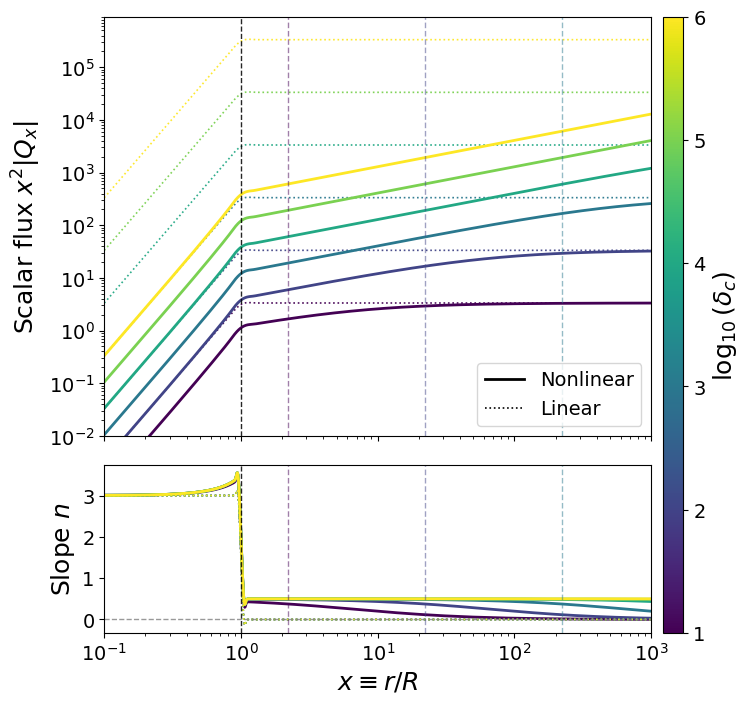

{0: {'xV_full': None, 'xV_mu': 2.370918315717885, 'delta_c': np.float64(10.0)},
 1: {'xV_full': None,
  'xV_mu': 5.107988666614577,
  'delta_c': np.float64(100.0)},
 2: {'xV_full': None,
  'xV_mu': 11.00482797964415,
  'delta_c': np.float64(1000.0)},
 3: {'xV_full': None,
  'xV_mu': 23.709183157178845,
  'delta_c': np.float64(10000.0)},
 4: {'xV_full': None,
  'xV_mu': 51.07988666614576,
  'delta_c': np.float64(100000.0)},
 5: {'xV_full': None,
  'xV_mu': 110.04827979644149,
  'delta_c': np.float64(1000000.0)}}

In [60]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from physics_utils import _cross_at_one
import matplotlib.cm as cm

# Two-panel figure: derivative (top) and slope n(x) (bottom) for Phaedrus sweep
fig, (ax_top, ax_bot), xV_map = plot_double_panel(
    x, sols,
    linrefs=linrefs,
    cmap_name="viridis",
    lw_num=2.0, lw_lin=1.2, lin_ls=":",
    smooth_win_deriv=61, smooth_poly_deriv=3,
    smooth_win_vain=21, smooth_poly_vain=3,
    S=S, delta_inf=delta_inf, eps_edge=eps_edge,
    figsize=(8, 8),
    vradius="none",  # disabled — we draw Phaedrus screening radii manually below
    vline_alpha=0.5, vline_lw=1.0, vline_ls="striped",
    show_horizontal_guides=False,
    label_fontsize=18,
    tick_fontsize=14,
    cbar_fontsize=18,
)

# Hide grid on both panels
for ax_ in [ax_top, ax_bot]:
    ax_.grid(True, which='major', alpha=0.0)
    ax_.grid(True, which='minor', alpha=0.0)

# n=0 reference line in slope panel
ax_bot.axhline(0.0, color='gray', ls='--', lw=1.0, alpha=0.8)

legend_elements = [
    Line2D([0], [0], color='black', lw=2.0, label='Nonlinear'),
    Line2D([0], [0], color='black', lw=1.2, linestyle=':', label='Linear'),
]
ax_top.legend(handles=legend_elements, loc='lower right', fontsize=14)

# Clip derivative panel from below
ax_top.set_ylim(bottom=1e-2)

# Fix slope panel ticks
ax_bot.set_yticks([0, 1, 2, 3])
ax_bot.set_yticklabels(['0', '1', '2', '3'], fontsize=14)

# --- Phaedrus screening radii: where D*|Q|/A = 1 (kinetic denominator doubles) ---
x_fine = np.logspace(np.log10(float(x[0])), np.log10(float(x[-1])), 3000)
norm_v = Normalize(vmin=np.log10(delta_cs.min()), vmax=np.log10(delta_cs.max()))
cmap_v = cm.get_cmap("viridis")

for sol_i, dc in zip(sols, delta_cs):
    meta = getattr(sol_i, "meta", {}) or {}
    pars = meta.get("pars_full", None)
    if pars is None:
        continue
    A_i, _, _, D_i, _, _, _ = pars
    if A_i == 0 or D_i == 0:
        continue
    Q_fine = sol_i.sol(x_fine)[0]
    ratio = D_i * np.abs(Q_fine) / abs(A_i)
    x_pscr = _cross_at_one(x_fine, ratio)
    if x_pscr is None:
        continue
    col = cmap_v(norm_v(np.log10(dc)))
    for ax_ in [ax_top, ax_bot]:
        ax_.axvline(x_pscr, color=col, ls=(0, (4, 2)), lw=1.0, alpha=0.5, label="_noref")

fig.savefig('phaedrus_double_panel.pdf', dpi=300, bbox_inches='tight')
plt.show()
xV_map